In [1]:
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup
import pandas as pd

Welcome to JupyROOT 6.28/10


In [5]:
path = '/scratch/group/mitchcomp/CDMS/data/perry5334/SourceSimOutput_decayAncestor_Spectrum/'
DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_steps_1thread_????????_??????.root'))
branches = ['EventNum', 'Parent', 'PName', 'KE', 'Edep', 'Time1', 'Time3', 'X1', 'Y1', 'Z1', 'X3', 'Y3', 'Z3', 'Track']

In [6]:
det = 1
mczipFrame = CDataFrame(f"G4SimDir/mczip{det}", DMCfiles)
mcDecaysFrame = CDataFrame("G4SimDir/mcDecays", DMCfiles)

In [7]:
mczip = mczipFrame.Filter('string(decayAncestor.PName.data()) == "Ge71"').AsNumpy(branches)
mcDecays = mcDecaysFrame.Filter('string(decayAncestor.PName.data()) == "Ge71"').Filter(f'DetNum=={det}').AsNumpy(branches)

In [8]:
mcDecays_EvtParent = np.array([(event, parent) for event in np.unique(mcDecays['EventNum']) for parent in np.unique(mcDecays['Parent'][mcDecays['EventNum'] == event])])
mczip_EvtParent = np.array([(event, parent) for event in np.unique(mczip['EventNum']) for parent in np.unique(mczip['Parent'][mczip['EventNum'] == event])])

mcDecays['KEsum'] = np.array([mcDecays['KE'][(mcDecays['Parent'] == parent) & (mcDecays['EventNum'] == event)].sum() for event, parent in mcDecays_EvtParent])
mczip['Edepsum'] = np.array([mczip['Edep'][(mczip['Parent'] == parent) & (mczip['EventNum'] == event)].sum() for event, parent in mczip_EvtParent])

In [10]:
mcDecays_EvtParent[(mcDecays['KEsum'] > 15e3) & (mcDecays['KEsum'] < 25e3)][0][0]

13045269.0

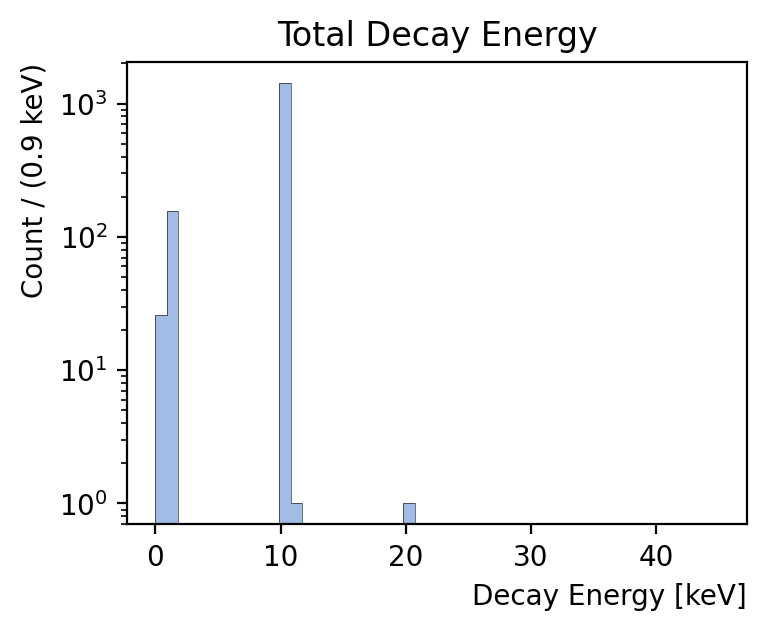

In [9]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 45, 51))
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 45, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.9 keV)')
plt.title('Total Decay Energy')
plt.yscale('log')

In [3]:
mcHitCounterFrame = CDataFrame("G4SimDir/mcHitCounter", DMCfiles)

In [88]:
#mcHitCounter = mcHitCounterFrame.Filter('EventNum==4001732.0').Filter('string(decayAncestor.PName.data()) == "Ge71"').AsNumpy(branches + ['Process','Xmom1', 'Ymom1', 'Zmom1'])

In [99]:
mcHitCounter = mcHitCounterFrame.Filter('EventNum==4001732.0').AsNumpy(branches + ['Process','Xmom1', 'Ymom1', 'Zmom1', 'decayAncestor.PName'])

In [76]:
pd.DataFrame(mcHitCounterFrame.Filter('EventNum==4001732.0').Filter('Parent==115').AsNumpy(branches + ['Process','Xmom1', 'Ymom1', 'Zmom1', 'decayAncestor.PName']))

,EventNum,Parent,PName,KE,Edep,Time1,Time3,X1,Y1,Z1,X3,Y3,Z3,Track,Process,Xmom1,Ymom1,Zmom1,decayAncestor.PName
0,4001732.0,115.0,e-,0.000000,0.000000,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,119.0,phot/phot,0.000000,-0.000000,0.000000,Ge71
1,4001732.0,115.0,e-,0.000000,0.000000,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,124.0,phot/phot_auger,-0.000000,0.000000,0.000000,Ge71
2,4001732.0,115.0,e-,8.630000,8.630000,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,124.0,phot/phot_auger,-141.387039,2876.650517,724.435763,Ge71
3,4001732.0,115.0,e-,7986.191811,476.948146,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,119.0,phot/phot,-16467.314520,-57350.536377,-68303.685191,Ge71
4,4001732.0,115.0,e-,0.000000,0.000000,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,120.0,phot/phot_auger,0.000000,0.000000,0.000000,Ge71
5,4001732.0,115.0,e-,968.440000,968.440000,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,120.0,phot/phot_auger,17581.968565,10613.777574,23851.699139,Ge71
6,4001732.0,115.0,e-,968.440000,0.000000,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,120.0,phot/phot_auger,14469.806457,-14827.667647,23694.860584,Ge71
7,4001732.0,115.0,e-,0.000000,0.000000,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,121.0,phot/phot_auger,0.000000,0.000000,-0.000000,Ge71
8,4001732.0,115.0,e-,52.370000,52.370000,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,121.0,phot/phot_auger,3376.796717,3044.344322,-5731.839150,Ge71
9,4001732.0,115.0,e-,0.000000,0.000000,1.430475e+14,1.430475e+14,0.010976,0.01261,-0.063634,0.010976,0.01261,-0.063634,122.0,phot/phot_auger,-0.000000,-0.000000,0.000000,Ge71


In [6]:
colors = {'e-': 'C0',
          'gamma': 'C2',
          'Ga71': '#D72B22',
          'Ge71': '#F9965C',
          'neutron': 'limegreen'}

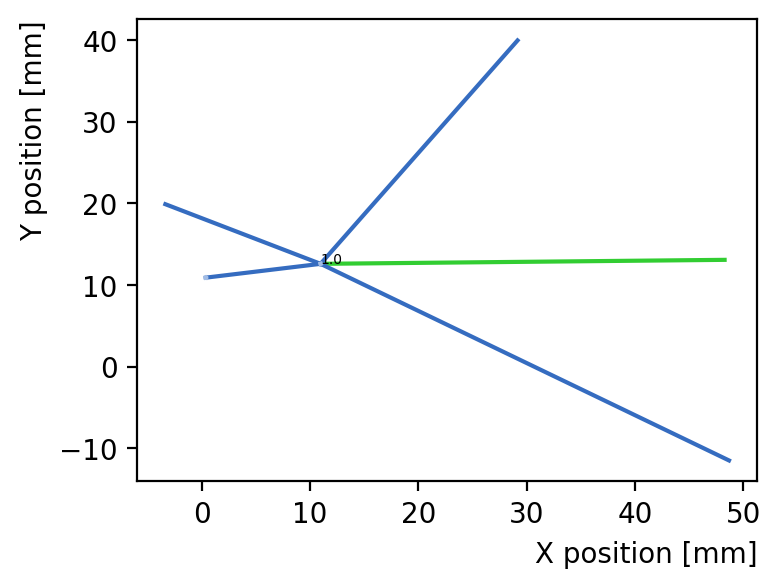

In [14]:
plt.figure(figsize = (4,3), dpi = 200)

xbegin, xend = 10, 12
ybegin, yend = 10, 14

for Track in np.unique(mcHitCounter['Track']):
    TrackCut = mcHitCounter['Track'] == Track
    #print(f"{mcHitCounter['Time1'][TrackCut]}: {mcHitCounter['Track'][TrackCut]}: {mcHitCounter['PName'][TrackCut]}: {mcHitCounter['KE'][TrackCut]*1e-3}")

    x1, y1, z1 = mcHitCounter['X1'][TrackCut]*1e3, mcHitCounter['Y1'][TrackCut]*1e3, mcHitCounter['Z1'][TrackCut]*1e3
    x3, y3, z3 = mcHitCounter['X3'][TrackCut]*1e3, mcHitCounter['Y3'][TrackCut]*1e3, mcHitCounter['Z3'][TrackCut]*1e3
    Time1, Time3 = mcHitCounter['Time1'][TrackCut], mcHitCounter['Time3'][TrackCut]

    X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
    Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
    Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
    T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
    R = np.sqrt(X**2 + Y**2)
    Tsort, Rsort, Zsort, Xsort, Ysort = zip(*sorted(zip(T, R, Z, X, Y)))

    plt.plot(Xsort, Ysort, color = colors[mcHitCounter['PName'][TrackCut][0]])

    if all(mcHitCounter['PName'][TrackCut] == 'neutron'):
        plt.text(X[-1], Y[-1], f"{np.unique(mcHitCounter['Track'][TrackCut])[0]}", fontsize = 5)

    #plt.xlim(xbegin, xend )
    #plt.ylim(ybegin, yend)
    plt.xlabel('X position [mm]')
    plt.ylabel('Y position [mm]')

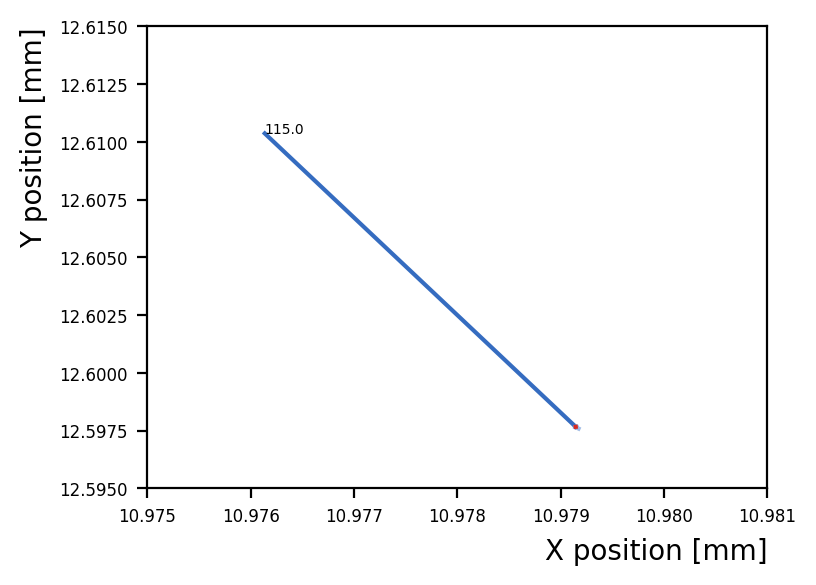

In [101]:
plt.figure(figsize = (4,3), dpi = 200)

xbegin, xend = 10.975, 10.981
ybegin, yend = 12.595, 12.615

for Track in tracks_20keV: #np.unique(mcHitCounter['Track']):
    TrackCut = mcHitCounter['Track'] == Track
    #print(f"{mcHitCounter['Time1'][TrackCut]}: {mcHitCounter['Track'][TrackCut]}: {mcHitCounter['PName'][TrackCut]}: {mcHitCounter['KE'][TrackCut]*1e-3}")

    x1, y1, z1 = mcHitCounter['X1'][TrackCut]*1e3, mcHitCounter['Y1'][TrackCut]*1e3, mcHitCounter['Z1'][TrackCut]*1e3
    x3, y3, z3 = mcHitCounter['X3'][TrackCut]*1e3, mcHitCounter['Y3'][TrackCut]*1e3, mcHitCounter['Z3'][TrackCut]*1e3
    Time1, Time3 = mcHitCounter['Time1'][TrackCut], mcHitCounter['Time3'][TrackCut]

    X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
    Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
    Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
    T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
    R = np.sqrt(X**2 + Y**2)
    Tsort, Rsort, Zsort, Xsort, Ysort = zip(*sorted(zip(T, R, Z, X, Y)))

    plt.plot(Xsort, Ysort, color = colors[mcHitCounter['PName'][TrackCut][0]])

    if all(mcHitCounter['PName'][TrackCut] == 'gamma') & (X[-1] > xbegin) & (X[-1] < xend) & (Y[-1] > ybegin) & (Y[-1] < yend):
        plt.text(X[-1], Y[-1], f"{np.unique(mcHitCounter['Track'][TrackCut])[0]}", fontsize = 5)

    plt.xlim(xbegin, xend )
    plt.ylim(ybegin, yend)
    plt.xlabel('X position [mm]')
    plt.ylabel('Y position [mm]')

    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

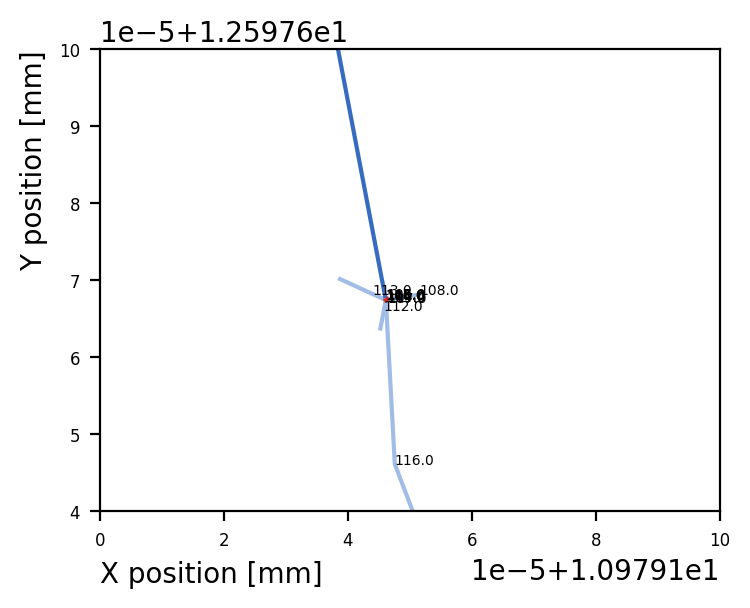

In [100]:
plt.figure(figsize = (4,3), dpi = 200)

xbegin, xend = 0.0091+1.097e1, 0.0092+1.097e1
ybegin, yend = 0.00064 + 1.2597e1, 0.0007 + 1.2597e1

for Track in tracks_20keV: #np.unique(mcHitCounter['Track']):
    TrackCut = mcHitCounter['Track'] == Track
    #print(f"{mcHitCounter['Time1'][TrackCut]}: {mcHitCounter['Track'][TrackCut]}: {mcHitCounter['PName'][TrackCut]}: {mcHitCounter['KE'][TrackCut]*1e-3}")

    x1, y1, z1 = mcHitCounter['X1'][TrackCut]*1e3, mcHitCounter['Y1'][TrackCut]*1e3, mcHitCounter['Z1'][TrackCut]*1e3
    x3, y3, z3 = mcHitCounter['X3'][TrackCut]*1e3, mcHitCounter['Y3'][TrackCut]*1e3, mcHitCounter['Z3'][TrackCut]*1e3
    Time1, Time3 = mcHitCounter['Time1'][TrackCut], mcHitCounter['Time3'][TrackCut]

    X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
    Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
    Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
    T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
    R = np.sqrt(X**2 + Y**2)
    Tsort, Rsort, Zsort, Xsort, Ysort = zip(*sorted(zip(T, R, Z, X, Y)))

    plt.plot(Xsort, Ysort, color = colors[mcHitCounter['PName'][TrackCut][0]])

    if all(mcHitCounter['PName'][TrackCut] == 'e-') & (X[-1] > xbegin) & (X[-1] < xend) & (Y[-1] > ybegin) & (Y[-1] < yend):
        plt.text(X[-1], Y[-1], f"{np.unique(mcHitCounter['Track'][TrackCut])[0]}", fontsize = 5)

    plt.xlim(xbegin, xend )
    plt.ylim(ybegin, yend)
    plt.xlabel('X position [mm]', loc = 'left')
    plt.ylabel('Y position [mm]')

    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

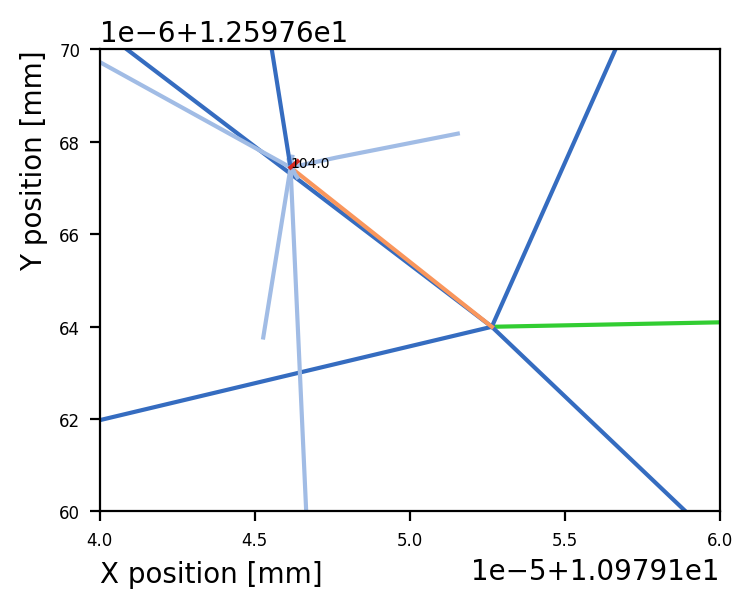

In [37]:
plt.figure(figsize = (4,3), dpi = 200)

xbegin, xend = 4e-5+1.09791e1, 6e-5+1.09791e1
ybegin, yend = 6e-5 + 1.25976e1, 7e-5 + 1.25976e1

for Track in np.unique(mcHitCounter['Track']):
    TrackCut = mcHitCounter['Track'] == Track
    #print(f"{mcHitCounter['Time1'][TrackCut]}: {mcHitCounter['Track'][TrackCut]}: {mcHitCounter['PName'][TrackCut]}: {mcHitCounter['KE'][TrackCut]*1e-3}")

    x1, y1, z1 = mcHitCounter['X1'][TrackCut]*1e3, mcHitCounter['Y1'][TrackCut]*1e3, mcHitCounter['Z1'][TrackCut]*1e3
    x3, y3, z3 = mcHitCounter['X3'][TrackCut]*1e3, mcHitCounter['Y3'][TrackCut]*1e3, mcHitCounter['Z3'][TrackCut]*1e3
    Time1, Time3 = mcHitCounter['Time1'][TrackCut], mcHitCounter['Time3'][TrackCut]

    X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
    Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
    Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
    T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
    R = np.sqrt(X**2 + Y**2)
    Tsort, Rsort, Zsort, Xsort, Ysort = zip(*sorted(zip(T, R, Z, X, Y)))

    plt.plot(Xsort, Ysort, color = colors[mcHitCounter['PName'][TrackCut][0]])

    if all(mcHitCounter['PName'][TrackCut] == 'Ge71') & (X[-1] > xbegin) & (X[-1] < xend) & (Y[-1] > ybegin) & (Y[-1] < yend):
        plt.text(X[-1], Y[-1], f"{np.unique(mcHitCounter['Track'][TrackCut])[0]}", fontsize = 5)

    plt.xlim(xbegin, xend )
    plt.ylim(ybegin, yend)
    plt.xlabel('X position [mm]', loc = 'left')
    plt.ylabel('Y position [mm]')

    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

In [7]:
mcHitCounter = mcHitCounterFrame.Filter('EventNum==4001732.0').Filter('string(decayAncestor.PName.data()) == "Ge71"').AsNumpy(branches + ['Process','Xmom1', 'Ymom1', 'Zmom1'])

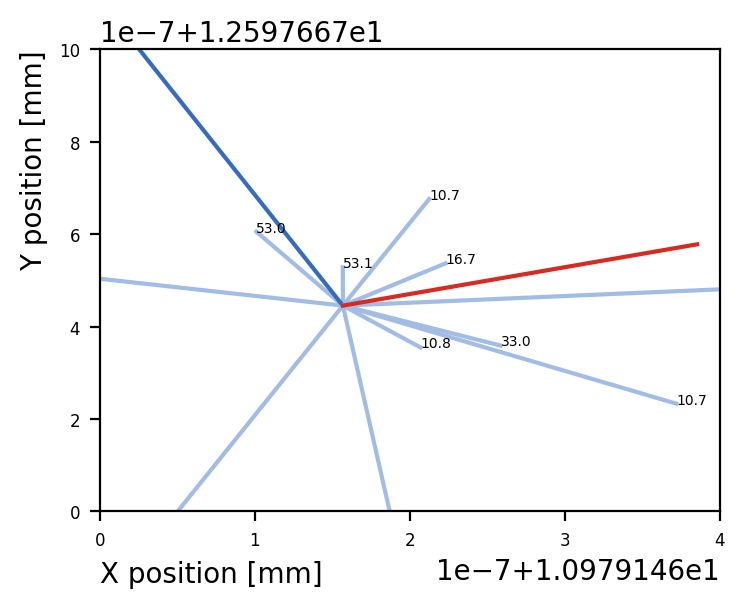

In [8]:
plt.figure(figsize = (4,3), dpi = 200)

xbegin, xend = 6e-6+1.097914e1, 6.4e-6+1.097914e1
ybegin, yend = 7e-6 + 1.259766e1, 8e-6 + 1.259766e1

for Track in np.unique(mcHitCounter['Track']):
    TrackCut = mcHitCounter['Track'] == Track
    #print(f"{mcHitCounter['Time1'][TrackCut]}: {mcHitCounter['Track'][TrackCut]}: {mcHitCounter['PName'][TrackCut]}: {mcHitCounter['KE'][TrackCut]*1e-3}")

    x1, y1, z1 = mcHitCounter['X1'][TrackCut]*1e3, mcHitCounter['Y1'][TrackCut]*1e3, mcHitCounter['Z1'][TrackCut]*1e3
    x3, y3, z3 = mcHitCounter['X3'][TrackCut]*1e3, mcHitCounter['Y3'][TrackCut]*1e3, mcHitCounter['Z3'][TrackCut]*1e3
    Time1, Time3 = mcHitCounter['Time1'][TrackCut], mcHitCounter['Time3'][TrackCut]

    X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
    Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
    Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
    T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
    R = np.sqrt(X**2 + Y**2)
    Tsort, Rsort, Zsort, Xsort, Ysort = zip(*sorted(zip(T, R, Z, X, Y)))

    plt.plot(Xsort, Ysort, color = colors[mcHitCounter['PName'][TrackCut][0]])

    if all(mcHitCounter['PName'][TrackCut] == 'e-') & (X[-1] > xbegin) & (X[-1] < xend) & (Y[-1] > ybegin) & (Y[-1] < yend):
        plt.text(X[-1], Y[-1], f"{max(mcHitCounter['KE'][TrackCut]):.3}", fontsize = 5)

    plt.xlim(xbegin, xend )
    plt.ylim(ybegin, yend)
    plt.xlabel('X position [mm]', loc = 'left')
    plt.ylabel('Y position [mm]')

    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

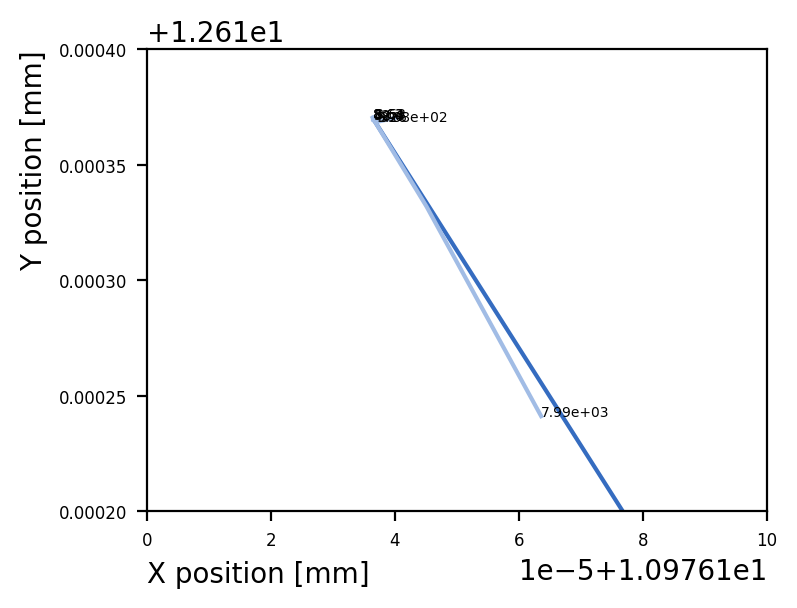

In [9]:
plt.figure(figsize = (4,3), dpi = 200)

xbegin, xend = 0.0001+1.0976e1, 0.0002+1.0976e1
ybegin, yend = 12.61 + 0.0002, 12.61 + 0.0004

for Track in np.unique(mcHitCounter['Track']):
    TrackCut = mcHitCounter['Track'] == Track
    #print(f"{mcHitCounter['Time1'][TrackCut]}: {mcHitCounter['Track'][TrackCut]}: {mcHitCounter['PName'][TrackCut]}: {mcHitCounter['KE'][TrackCut]*1e-3}")

    x1, y1, z1 = mcHitCounter['X1'][TrackCut]*1e3, mcHitCounter['Y1'][TrackCut]*1e3, mcHitCounter['Z1'][TrackCut]*1e3
    x3, y3, z3 = mcHitCounter['X3'][TrackCut]*1e3, mcHitCounter['Y3'][TrackCut]*1e3, mcHitCounter['Z3'][TrackCut]*1e3
    Time1, Time3 = mcHitCounter['Time1'][TrackCut], mcHitCounter['Time3'][TrackCut]

    X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
    Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
    Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
    T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
    R = np.sqrt(X**2 + Y**2)
    Tsort, Rsort, Zsort, Xsort, Ysort = zip(*sorted(zip(T, R, Z, X, Y)))

    plt.plot(Xsort, Ysort, color = colors[mcHitCounter['PName'][TrackCut][0]])

    if all(mcHitCounter['PName'][TrackCut] == 'e-') & (X[-1] > xbegin) & (X[-1] < xend) & (Y[-1] > ybegin) & (Y[-1] < yend):
        plt.text(X[-1], Y[-1], f"{max(mcHitCounter['KE'][TrackCut]):.3}", fontsize = 5)

    plt.xlim(xbegin, xend )
    plt.ylim(ybegin, yend)
    plt.xlabel('X position [mm]', loc = 'left')
    plt.ylabel('Y position [mm]')

    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

In [18]:
mcHitCounter = mcHitCounterFrame.Filter('EventNum==4001732.0').AsNumpy(branches + ['Process','Xmom1', 'Ymom1', 'Zmom1', 'decayAncestor.PName'])

[1.]: ['Primary']: ['neutron']: [4.64203822e-05]
[100.]: ['nCapture']: ['gamma']: [6036.99533254]
[101.]: ['nCapture']: ['gamma']: [631.47715565]
[102.]: ['nCapture']: ['gamma']: [572.30020937]
[103.]: ['nCapture']: ['gamma']: [174.953018]
[104. 104.]: ['nCapture' 'nCapture']: ['Ge71' 'Ge71']: [0.23043205 0.        ]
[105. 105.]: ['RadioactiveDecayBase/annihil' 'RadioactiveDecayBase/annihil']: ['e-' 'e-']: [0.01068752 0.        ]
[106. 106.]: ['RadioactiveDecayBase/annihil' 'RadioactiveDecayBase/annihil']: ['e-' 'e-']: [0.05305594 0.        ]
[107. 107.]: ['RadioactiveDecayBase/annihil' 'RadioactiveDecayBase/annihil']: ['e-' 'e-']: [0.         0.01068574]
[108. 108. 108.]: ['RadioactiveDecayBase/annihil' 'RadioactiveDecayBase/annihil'
 'RadioactiveDecayBase/annihil']: ['e-' 'e-' 'e-']: [0.98793946 0.98793946 0.        ]
[109. 109.]: ['RadioactiveDecayBase/annihil' 'RadioactiveDecayBase/annihil']: ['e-' 'e-']: [0.01079655 0.        ]
[110. 110.]: ['RadioactiveDecayBase/annihil' 'Radioac

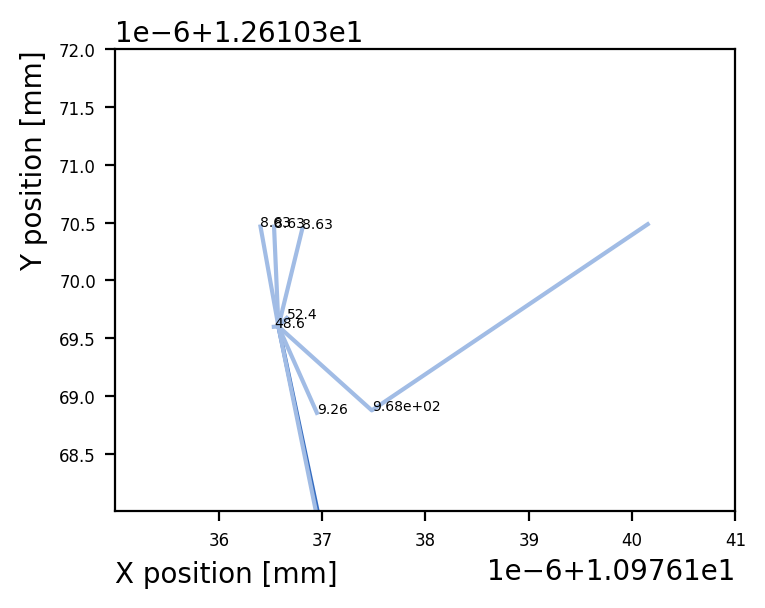

In [20]:
plt.figure(figsize = (4,3), dpi = 200)

xbegin, xend = 3.5e-5+1.09761e1, 4.1e-5+1.09761e1
ybegin, yend = 12.6103 + 6.8e-5, 12.6103 + 7.2e-5

for Track in np.unique(mcHitCounter['Track']):
    TrackCut = mcHitCounter['Track'] == Track
    print(f"{mcHitCounter['Track'][TrackCut]}: {mcHitCounter['Process'][TrackCut]}: {mcHitCounter['PName'][TrackCut]}: {mcHitCounter['KE'][TrackCut]*1e-3}")

    x1, y1, z1 = mcHitCounter['X1'][TrackCut]*1e3, mcHitCounter['Y1'][TrackCut]*1e3, mcHitCounter['Z1'][TrackCut]*1e3
    x3, y3, z3 = mcHitCounter['X3'][TrackCut]*1e3, mcHitCounter['Y3'][TrackCut]*1e3, mcHitCounter['Z3'][TrackCut]*1e3
    Time1, Time3 = mcHitCounter['Time1'][TrackCut], mcHitCounter['Time3'][TrackCut]

    X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
    Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
    Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
    T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
    R = np.sqrt(X**2 + Y**2)
    Tsort, Rsort, Zsort, Xsort, Ysort = zip(*sorted(zip(T, R, Z, X, Y)))

    plt.plot(Xsort, Ysort, color = colors[mcHitCounter['PName'][TrackCut][0]])

    if all(mcHitCounter['PName'][TrackCut] == 'e-') & (X[-1] > xbegin) & (X[-1] < xend) & (Y[-1] > ybegin) & (Y[-1] < yend):
        plt.text(X[-1], Y[-1], f"{max(mcHitCounter['KE'][TrackCut]):.3}", fontsize = 5)

    plt.xlim(xbegin, xend )
    plt.ylim(ybegin, yend)
    plt.xlabel('X position [mm]', loc = 'left')
    plt.ylabel('Y position [mm]')

    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

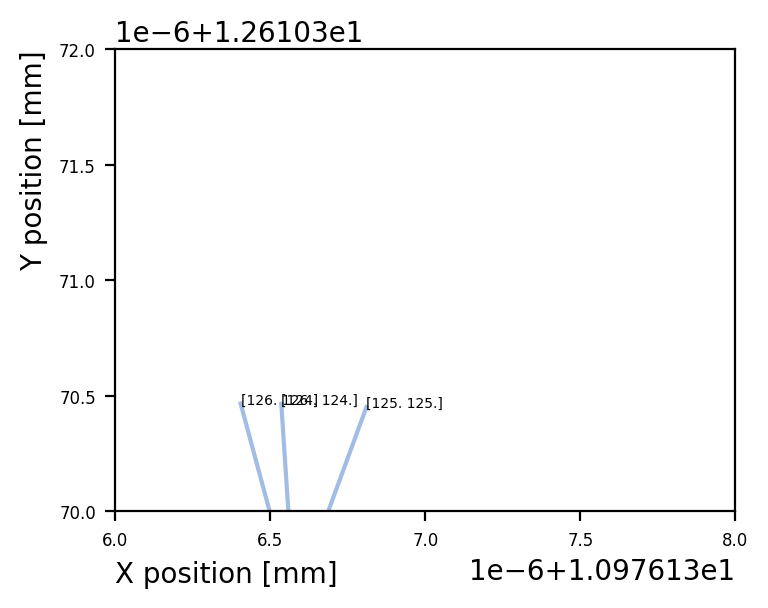

In [103]:
plt.figure(figsize = (4,3), dpi = 200)

xbegin, xend = 3.6e-5+1.09761e1, 3.8e-5+1.09761e1
ybegin, yend = 12.6103 + 7e-5, 12.6103 + 7.2e-5

for Track in np.unique(mcHitCounter['Track']):
    TrackCut = mcHitCounter['Track'] == Track
    #print(f"{mcHitCounter['Time1'][TrackCut]}: {mcHitCounter['Track'][TrackCut]}: {mcHitCounter['PName'][TrackCut]}: {mcHitCounter['KE'][TrackCut]*1e-3}")

    x1, y1, z1 = mcHitCounter['X1'][TrackCut]*1e3, mcHitCounter['Y1'][TrackCut]*1e3, mcHitCounter['Z1'][TrackCut]*1e3
    x3, y3, z3 = mcHitCounter['X3'][TrackCut]*1e3, mcHitCounter['Y3'][TrackCut]*1e3, mcHitCounter['Z3'][TrackCut]*1e3
    Time1, Time3 = mcHitCounter['Time1'][TrackCut], mcHitCounter['Time3'][TrackCut]

    X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
    Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
    Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
    T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
    R = np.sqrt(X**2 + Y**2)
    Tsort, Rsort, Zsort, Xsort, Ysort = zip(*sorted(zip(T, R, Z, X, Y)))

    plt.plot(Xsort, Ysort, color = colors[mcHitCounter['PName'][TrackCut][0]])

    if all(mcHitCounter['PName'][TrackCut] == 'e-') & (X[-1] > xbegin) & (X[-1] < xend) & (Y[-1] > ybegin) & (Y[-1] < yend):
        plt.text(X[-1], Y[-1], f"{mcHitCounter['Track'][TrackCut]}", fontsize = 5)

    plt.xlim(xbegin, xend )
    plt.ylim(ybegin, yend)
    plt.xlabel('X position [mm]', loc = 'left')
    plt.ylabel('Y position [mm]')

    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)